In [10]:
import pandas as pd
#Load the data
df = pd.read_csv('C:/Users/USER/Desktop/sales_data_1000.csv')
print(df.head())

   OrderID        Date             CustomerName            Product  Quantity  \
0     1001  2025-01-16              Tonya Moore             Tablet         3   
1     1002  2024-10-09             Betty Garcia             Laptop         1   
2     1003  2025-04-10  Mr. Christopher Jimenez            Monitor         1   
3     1004  2024-05-07              Gloria Kirk  Bluetooth Speaker         4   
4     1005  2024-10-07           Anthony Brooks         Headphones         1   

   PricePerUnit  TotalPrice  
0         20000       60000  
1         55000       55000  
2         12000       12000  
3          3000       12000  
4          1500        1500  


In [11]:
print(df.isnull().sum())

OrderID         0
Date            0
CustomerName    0
Product         0
Quantity        0
PricePerUnit    0
TotalPrice      0
dtype: int64


In [12]:
df = df.drop('PricePerUnit',axis=1)
print(df.columns)

Index(['OrderID', 'Date', 'CustomerName', 'Product', 'Quantity', 'TotalPrice'], dtype='object')


In [13]:
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool


In [14]:
print(df.dtypes)

OrderID          int64
Date            object
CustomerName    object
Product         object
Quantity         int64
TotalPrice       int64
dtype: object


In [15]:
df['Date']=pd.to_datetime(df['Date'])

In [17]:
df['TotalPrice']=df['TotalPrice'].astype(float)
print(df.dtypes)

OrderID                  int64
Date            datetime64[ns]
CustomerName            object
Product                 object
Quantity                 int64
TotalPrice             float64
dtype: object


In [46]:
print(df.describe())
import numpy as np

           OrderID                        Date     Quantity     TotalPrice  \
count  1000.000000                        1000  1000.000000    1000.000000   
mean   1500.500000  2024-10-27 11:44:09.600000     3.009000   39106.200000   
min    1001.000000         2024-04-27 00:00:00     1.000000     800.000000   
25%    1250.750000         2024-07-28 18:00:00     2.000000    4000.000000   
50%    1500.500000         2024-10-25 12:00:00     3.000000   14000.000000   
75%    1750.250000         2025-01-30 00:00:00     4.000000   48000.000000   
max    2000.000000         2025-04-27 00:00:00     5.000000  275000.000000   
std     288.819436                         NaN     1.424411   60477.992933   

             Year        Month          Day  
count  1000.00000  1000.000000  1000.000000  
mean   2024.32000     6.557000    15.486000  
min    2024.00000     1.000000     1.000000  
25%    2024.00000     4.000000     8.000000  
50%    2024.00000     7.000000    15.000000  
75%    2025.00000    

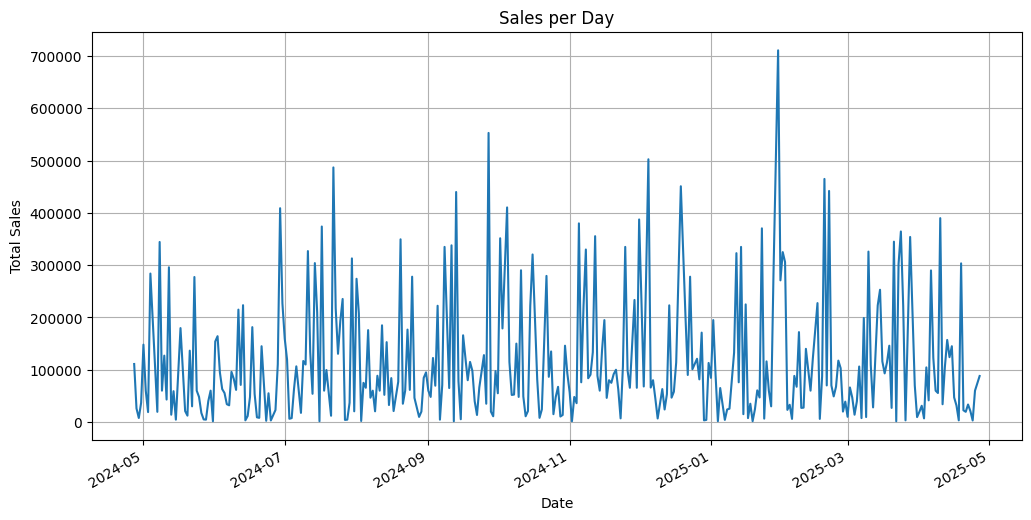

In [21]:
import matplotlib.pyplot as plt

sales_per_day = df.groupby('Date')['TotalPrice'].sum()

#Plotting the sales per day
plt.figure(figsize=(12,6))
sales_per_day.plot()
plt.title('Sales per Day')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid()
plt.show()


In [23]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [24]:
#montly total sales
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
#year-month column 
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str) + '-01')
#sorting
monthly_sales = monthly_sales.sort_values(by='YearMonth')
print(monthly_sales)

    Year  Month  TotalPrice  YearMonth
0   2024      4    181500.0 2024-04-01
1   2024      5   2371600.0 2024-05-01
2   2024      6   2637200.0 2024-06-01
3   2024      7   3987400.0 2024-07-01
4   2024      8   2895900.0 2024-08-01
5   2024      9   3284200.0 2024-09-01
6   2024     10   3334700.0 2024-10-01
7   2024     11   3661700.0 2024-11-01
8   2024     12   3863400.0 2024-12-01
9   2025      1   3620400.0 2025-01-01
10  2025      2   3161500.0 2025-02-01
11  2025      3   3786200.0 2025-03-01
12  2025      4   2320500.0 2025-04-01


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# X ->month number, y -> total sales
monthly_sales['MonthNum'] = range(1, len(monthly_sales) + 1)

X = monthly_sales[['MonthNum']]
y = monthly_sales['TotalPrice']


In [31]:
#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Creating the model
model = LinearRegression()
model.fit(X_train, y_train)

#Making predictions
y_pred = model.predict(X_test)
print(y_pred)

[3189837.09677419 3175211.29032258 3109395.16129032]


In [49]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)

Mean Squared Error: 3042137258358.4805
Mean Absolute Error: 1323148.9247311829


In [62]:
#Last months number
last_month_num = monthly_sales['MonthNum'].max() + 1
#Predicting the next 6 month sales
future_months = pd.DataFrame({'MonthNum': range(last_month_num, last_month_num + 6)})
future_sales = model.predict(future_months)
print(future_sales)


[3204462.90322581 3211775.80645161 3219088.70967742 3226401.61290323
 3233714.51612903 3241027.41935484]
